Found 7750 images belonging to 2 classes.
Found 328 images belonging to 2 classes.
Found 780 images belonging to 2 classes.


C:\Users\Bsi\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 346s 1s/step - accuracy: 0.8581 - loss: 0.3202 - val_accuracy: 0.8811 - val_loss: 0.2630
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 203s 833ms/step - accuracy: 0.9331 - loss: 0.1726 - val_accuracy: 1.0000 - val_loss: 0.2731
Epoch 3/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 203s 836ms/step - accuracy: 0.9400 - loss: 0.1559 - val_accuracy: 0.8811 - val_loss: 0.3456
Epoch 4/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 202s 831ms/step - accuracy: 0.9392 - loss: 0.1525 - val_accuracy: 0.8811 - val_loss: 0.2465
Epoch 5/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 237s 976ms/step - accuracy: 0.9418 - loss: 0.1483 - val_accuracy: 0.9268 - val_loss: 0.2117
Epoch 6/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 296s 1s/step - accuracy: 0.9455 - loss: 0.1446 - val_accuracy: 0.8079 - val_loss: 0.3363
Epoch 7/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 204s 839ms/step - accuracy: 0.9474 - loss: 0.1468 - val_accuracy: 0.8811 - val_loss: 0.1806
Epoch 8/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 204s 838ms/step - accuracy: 0.9479 - loss:

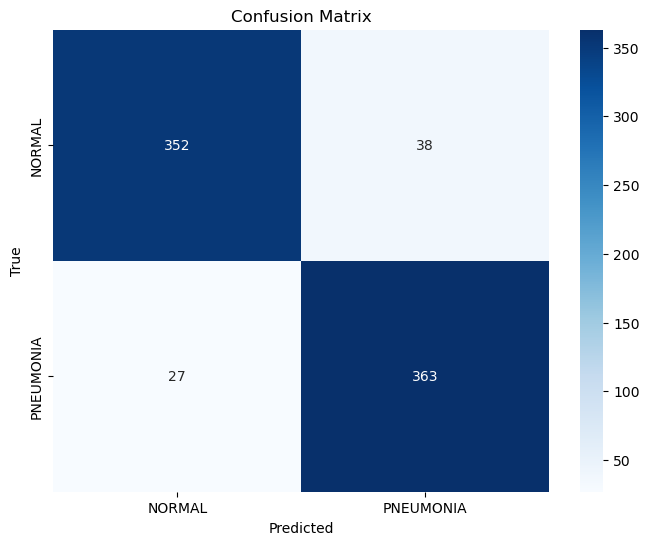

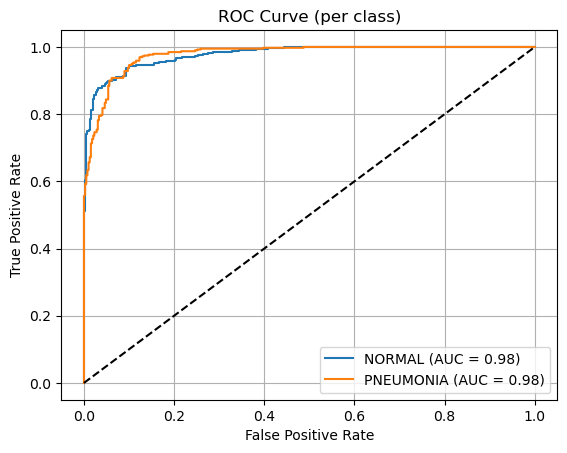

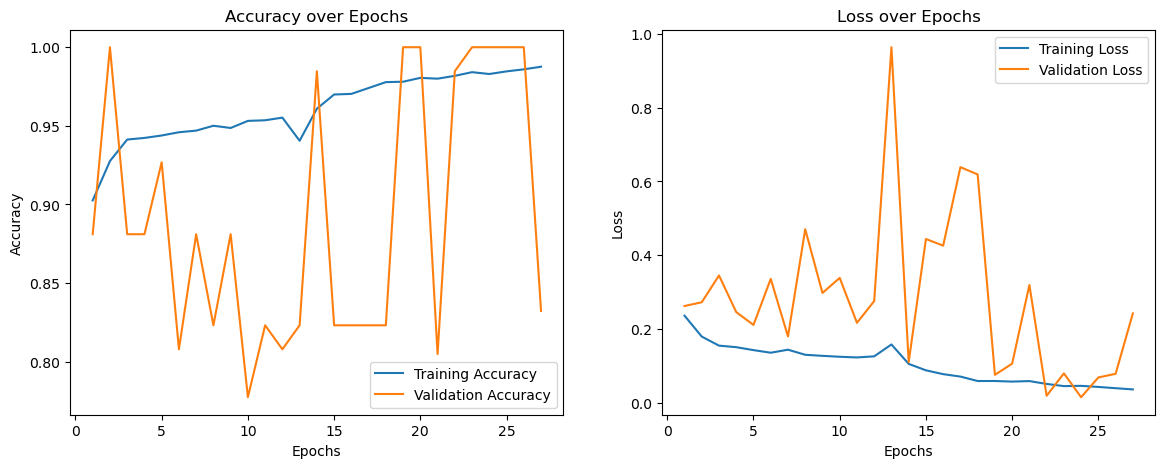

In [57]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
#preparation de donnees
train_dir = 'D:/Data-Chest-ray/train'
val_dir = 'D:/Data-Chest-ray/val'
test_dir = 'D:/Data-Chest-ray/test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE,
                                              batch_size=BATCH_SIZE, class_mode='categorical')
val_gen = val_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE,
                                          batch_size=BATCH_SIZE, class_mode='categorical')
test_gen = val_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE,
                                           batch_size=1, class_mode='categorical', shuffle=False)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(train_gen.num_classes, activation='softmax')
])
model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
class_weights = {0: 1.0, 1: 3.0}  # Adjust the weights for NORMAL and PNEUMONIA

history_1 = model.fit(train_gen, validation_data=val_gen, epochs=20, callbacks=[early_stop])

# Fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

history_2 = model.fit(train_gen, validation_data=val_gen, epochs=15, callbacks=[early_stop])
# Prédictions
pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes
target_names = list(test_gen.class_indices.keys())

# Rapport de classification
print(classification_report(y_true, y_pred, target_names=target_names))

# F1-score
f1 = f1_score(y_true, y_pred, average='macro')
print("F1-score (macro):", f1)

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Courbes ROC pour chaque classe
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(len(target_names)):
    fpr[i], tpr[i], _ = roc_curve(test_gen.labels == i, pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (per class)')
plt.legend()
plt.grid(True)
plt.show()
def plot_learning_curves(history_list, labels):
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs_range = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Appeler la fonction
plot_learning_curves([history_1, history_2], ['Phase 1', 'Phase 2'])

In [59]:
import matplotlib.pyplot as plt

fig_dir = 'D:/Data-Chest-ray'
os.makedirs(fig_dir, exist_ok=True)

# Courbe d'apprentissage
def save_learning_curves(history_list, save_path):
    acc, val_acc, loss, val_loss = [], [], [], []
    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.legend()

    plt.savefig(os.path.join(save_path, 'learning_curves.png'))
    plt.close()

save_learning_curves([history_1, history_2], fig_dir)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'confusion_matrix.png'))
plt.close()
plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'roc_curve.png'))
plt.close()



In [61]:
# save
model_save_path = 'D:/Data-Chest-ray'
os.makedirs(model_save_path, exist_ok=True)

# Sauvegarder le modèle final
model.save(os.path.join(model_save_path, 'MobileNetV20.7B_finetuned_model.h5'))
print("✅ Modèle enregistré avec succès dans pc.")

✅ Modèle enregistré avec succès dans pc.


In [63]:
for i, label in enumerate(target_names):
    class_indices = np.where(y_true == i)[0]
    class_y_pred = y_pred[class_indices]
    class_y_true = y_true[class_indices]
    class_f1 = f1_score(class_y_true, class_y_pred, average='macro')
    acc = np.mean(class_y_pred == class_y_true)
    print(f"🔍 Classe: {label} — Accuracy: {acc:.2f}, F1-score: {class_f1:.2f}")


🔍 Classe: NORMAL — Accuracy: 0.90, F1-score: 0.47
🔍 Classe: PNEUMONIA — Accuracy: 0.93, F1-score: 0.48


In [65]:
model.save(os.path.join(model_save_path, 'MobileNetV2_finetuned.keras'))


In [71]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Même preprocessing que pour l'entraînement
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    'D:/Data-Chest-ray/test',  # ← Mets ici le bon chemin
    target_size=(224, 224),  # Même taille que pour MobileNetV2
    batch_size=32,
    class_mode='categorical',  # Important pour la prédiction de probabilités
    shuffle=False  # Important pour correspondance avec y_true
)


Found 780 images belonging to 2 classes.


In [73]:
y_prob = model.predict(test_generator)


C:\Users\Bsi\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 596ms/step


In [75]:
from sklearn.preprocessing import label_binarize

# Si test_generator.class_indices = {'NORMAL': 0, 'PNEUMONIA': 1}
y_true = test_generator.classes
y_true_bin = label_binarize(y_true, classes=[0, 1])  # pour avoir [0] ou [1]


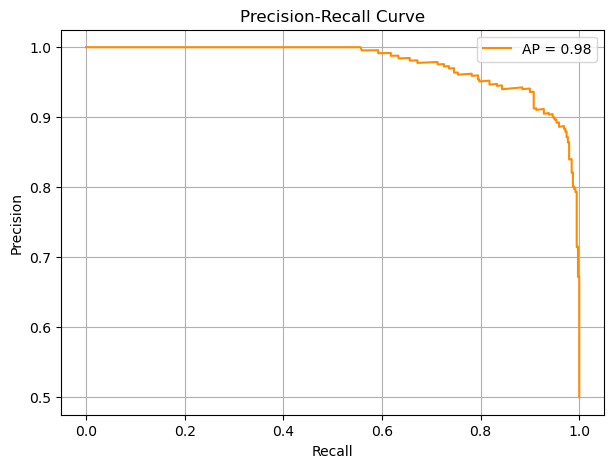

In [77]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Probabilités pour la classe PNEUMONIA (indice 1)
y_scores = y_prob[:, 1]

precision, recall, thresholds = precision_recall_curve(y_true_bin, y_scores)
average_precision = average_precision_score(y_true_bin, y_scores)

# Tracé
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f'AP = {average_precision:.2f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()


In [79]:
import numpy as np

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print(f"Seuil optimal (max F1): {best_threshold:.2f}, F1-score: {f1_scores[best_index]:.3f}")


Seuil optimal (max F1): 0.13, F1-score: 0.926


Classification Report (seuil optimisé) :
              precision    recall  f1-score   support

      NORMAL       0.97      0.88      0.92       390
   PNEUMONIA       0.89      0.97      0.93       390

    accuracy                           0.92       780
   macro avg       0.93      0.92      0.92       780
weighted avg       0.93      0.92      0.92       780



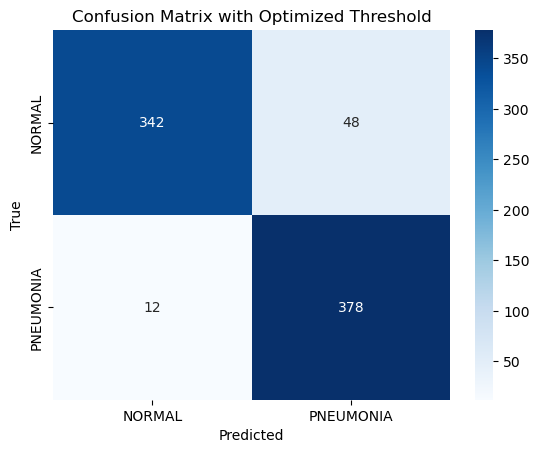

In [81]:
y_pred_thresholded = (y_scores >= best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report (seuil optimisé) :")
print(classification_report(y_true_bin, y_pred_thresholded, target_names=['NORMAL', 'PNEUMONIA']))

cm = confusion_matrix(y_true_bin, y_pred_thresholded)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix with Optimized Threshold')
plt.show()


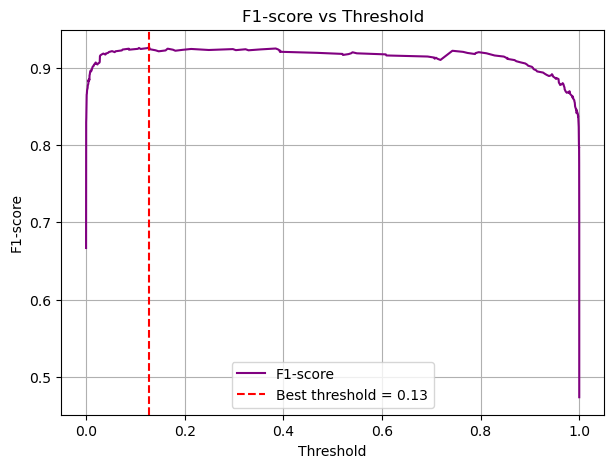

In [83]:
plt.figure(figsize=(7, 5))
plt.plot(thresholds, f1_scores[:-1], label="F1-score", color="purple")
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f"Best threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("F1-score vs Threshold")
plt.legend()
plt.grid()
plt.show()


In [123]:
for i, layer in enumerate(model.layers):
    print(f"{i}: {layer.name}")


0: mobilenetv2_1.00_224
1: global_average_pooling2d_1
2: dense_3
3: dropout_2
4: dense_4
5: dropout_3
6: dense_5


In [125]:
for i, layer in enumerate(model.get_layer('mobilenetv2_1.00_224').layers):
    print(f"{i}: {layer.name}")


0: input_layer_2
1: Conv1
2: bn_Conv1
3: Conv1_relu
4: expanded_conv_depthwise
5: expanded_conv_depthwise_BN
6: expanded_conv_depthwise_relu
7: expanded_conv_project
8: expanded_conv_project_BN
9: block_1_expand
10: block_1_expand_BN
11: block_1_expand_relu
12: block_1_pad
13: block_1_depthwise
14: block_1_depthwise_BN
15: block_1_depthwise_relu
16: block_1_project
17: block_1_project_BN
18: block_2_expand
19: block_2_expand_BN
20: block_2_expand_relu
21: block_2_depthwise
22: block_2_depthwise_BN
23: block_2_depthwise_relu
24: block_2_project
25: block_2_project_BN
26: block_2_add
27: block_3_expand
28: block_3_expand_BN
29: block_3_expand_relu
30: block_3_pad
31: block_3_depthwise
32: block_3_depthwise_BN
33: block_3_depthwise_relu
34: block_3_project
35: block_3_project_BN
36: block_4_expand
37: block_4_expand_BN
38: block_4_expand_relu
39: block_4_depthwise
40: block_4_depthwise_BN
41: block_4_depthwise_relu
42: block_4_project
43: block_4_project_BN
44: block_4_add
45: block_5_exp

Found 7750 images belonging to 2 classes.
Found 328 images belonging to 2 classes.
Found 780 images belonging to 2 classes.


C:\Users\Bsi\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 360s 1s/step - accuracy: 0.7306 - loss: 0.6821 - val_accuracy: 0.8811 - val_loss: 0.3667
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 237s 974ms/step - accuracy: 0.8957 - loss: 0.2710 - val_accuracy: 0.7774 - val_loss: 0.3594
Epoch 3/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 217s 892ms/step - accuracy: 0.9085 - loss: 0.2397 - val_accuracy: 0.7774 - val_loss: 0.3601
Epoch 4/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 228s 940ms/step - accuracy: 0.9109 - loss: 0.2199 - val_accuracy: 0.8811 - val_loss: 0.2953
Epoch 5/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 215s 883ms/step - accuracy: 0.9165 - loss: 0.2290 - val_accuracy: 0.8811 - val_loss: 0.3012
Epoch 6/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 203s 834ms/step - accuracy: 0.9126 - loss: 0.2232 - val_accuracy: 0.7774 - val_loss: 0.4093
Epoch 7/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 211s 867ms/step - accuracy: 0.9192 - loss: 0.2099 - val_accuracy: 0.8811 - val_loss: 0.3075
Epoch 8/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 215s 886ms/step - accuracy: 0.9193 - lo

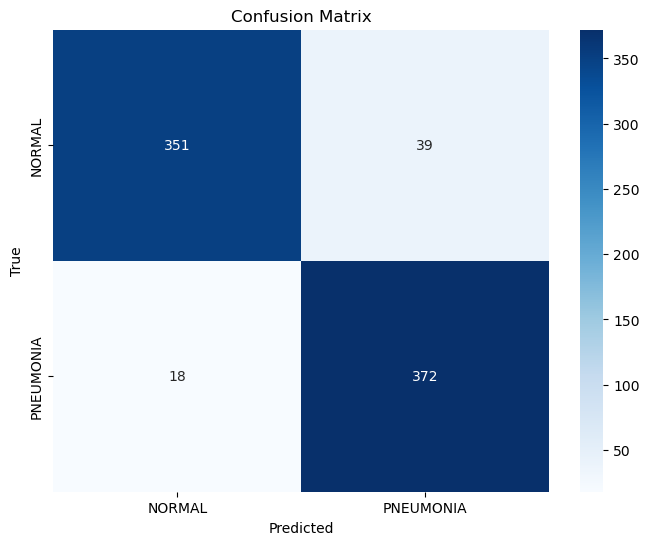

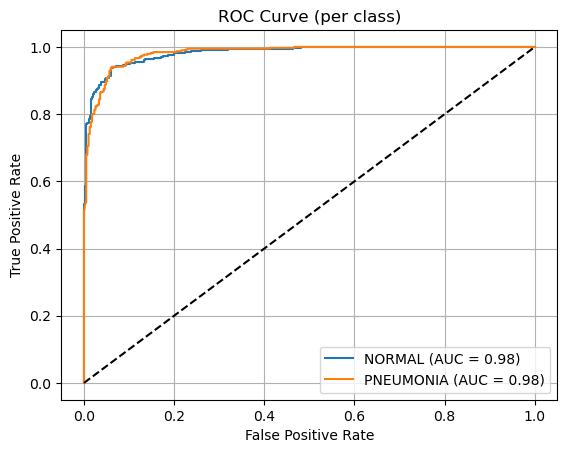

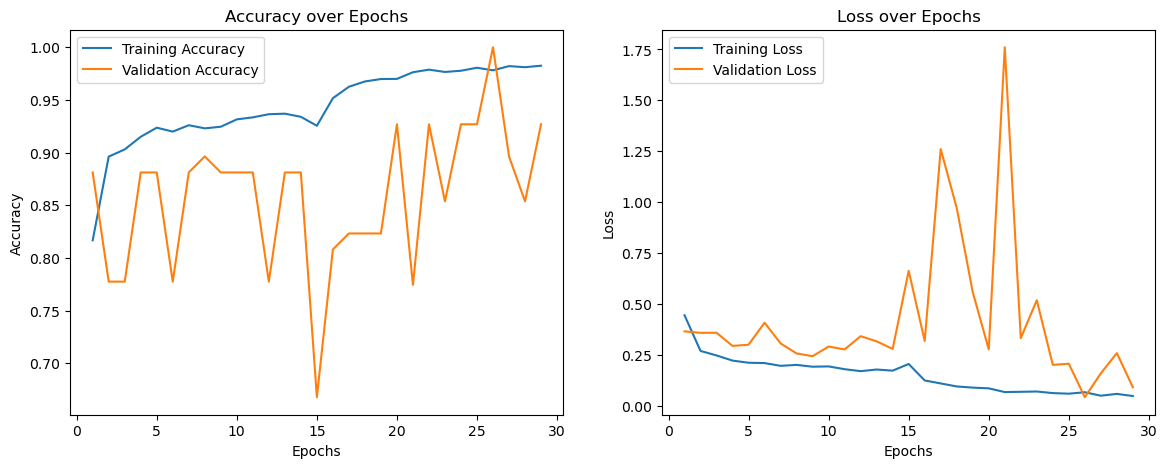

In [127]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
#preparation de donnees
train_dir = 'D:/Data-Chest-ray/train'
val_dir = 'D:/Data-Chest-ray/val'
test_dir = 'D:/Data-Chest-ray/test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE,
                                              batch_size=BATCH_SIZE, class_mode='categorical')
val_gen = val_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE,
                                          batch_size=BATCH_SIZE, class_mode='categorical')
test_gen = val_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE,
                                           batch_size=1, class_mode='categorical', shuffle=False)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.7),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.7),
    layers.Dense(train_gen.num_classes, activation='softmax')
])
model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
class_weights = {0: 1.0, 1: 3.0}  # Adjust the weights for NORMAL and PNEUMONIA

history_1 = model.fit(train_gen, validation_data=val_gen, epochs=20, callbacks=[early_stop])

# Fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

history_2 = model.fit(train_gen, validation_data=val_gen, epochs=15, callbacks=[early_stop])
# Prédictions
pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes
target_names = list(test_gen.class_indices.keys())

# Rapport de classification
print(classification_report(y_true, y_pred, target_names=target_names))

# F1-score
f1 = f1_score(y_true, y_pred, average='macro')
print("F1-score (macro):", f1)

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Courbes ROC pour chaque classe
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(len(target_names)):
    fpr[i], tpr[i], _ = roc_curve(test_gen.labels == i, pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (per class)')
plt.legend()
plt.grid(True)
plt.show()
def plot_learning_curves(history_list, labels):
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs_range = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Appeler la fonction
plot_learning_curves([history_1, history_2], ['Phase 1', 'Phase 2'])

In [129]:
import matplotlib.pyplot as plt

fig_dir = 'D:/Data-Chest-ray'
os.makedirs(fig_dir, exist_ok=True)

# Courbe d'apprentissage
def save_learning_curves(history_list, save_path):
    acc, val_acc, loss, val_loss = [], [], [], []
    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.legend()

    plt.savefig(os.path.join(save_path, 'learning_curves.png'))
    plt.close()

save_learning_curves([history_1, history_2], fig_dir)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'confusion_matrix.png'))
plt.close()
plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'roc_curve.png'))
plt.close()



In [131]:
for i, label in enumerate(target_names):
    class_indices = np.where(y_true == i)[0]
    class_y_pred = y_pred[class_indices]
    class_y_true = y_true[class_indices]
    class_f1 = f1_score(class_y_true, class_y_pred, average='macro')
    acc = np.mean(class_y_pred == class_y_true)
    print(f"🔍 Classe: {label} — Accuracy: {acc:.2f}, F1-score: {class_f1:.2f}")


🔍 Classe: NORMAL — Accuracy: 0.90, F1-score: 0.47
🔍 Classe: PNEUMONIA — Accuracy: 0.95, F1-score: 0.49


In [133]:
import numpy as np

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print(f"Seuil optimal (max F1): {best_threshold:.2f}, F1-score: {f1_scores[best_index]:.3f}")


Seuil optimal (max F1): 0.13, F1-score: 0.926


Classification Report (seuil optimisé) :
              precision    recall  f1-score   support

      NORMAL       0.97      0.88      0.92       390
   PNEUMONIA       0.89      0.97      0.93       390

    accuracy                           0.92       780
   macro avg       0.93      0.92      0.92       780
weighted avg       0.93      0.92      0.92       780



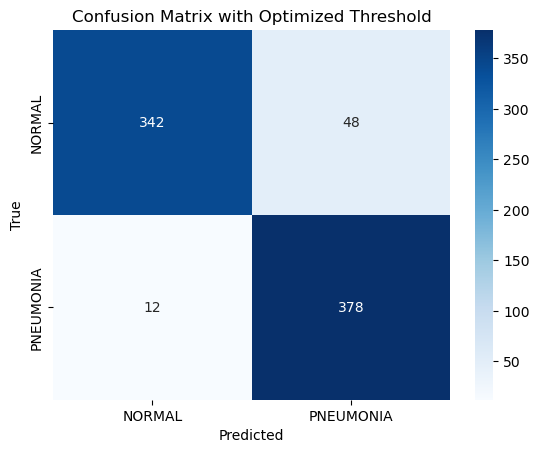

In [135]:
y_pred_thresholded = (y_scores >= best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report (seuil optimisé) :")
print(classification_report(y_true_bin, y_pred_thresholded, target_names=['NORMAL', 'PNEUMONIA']))

cm = confusion_matrix(y_true_bin, y_pred_thresholded)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix with Optimized Threshold')
plt.show()


C:\Users\Bsi\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


780/780 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step
Nombre d'erreurs : 57


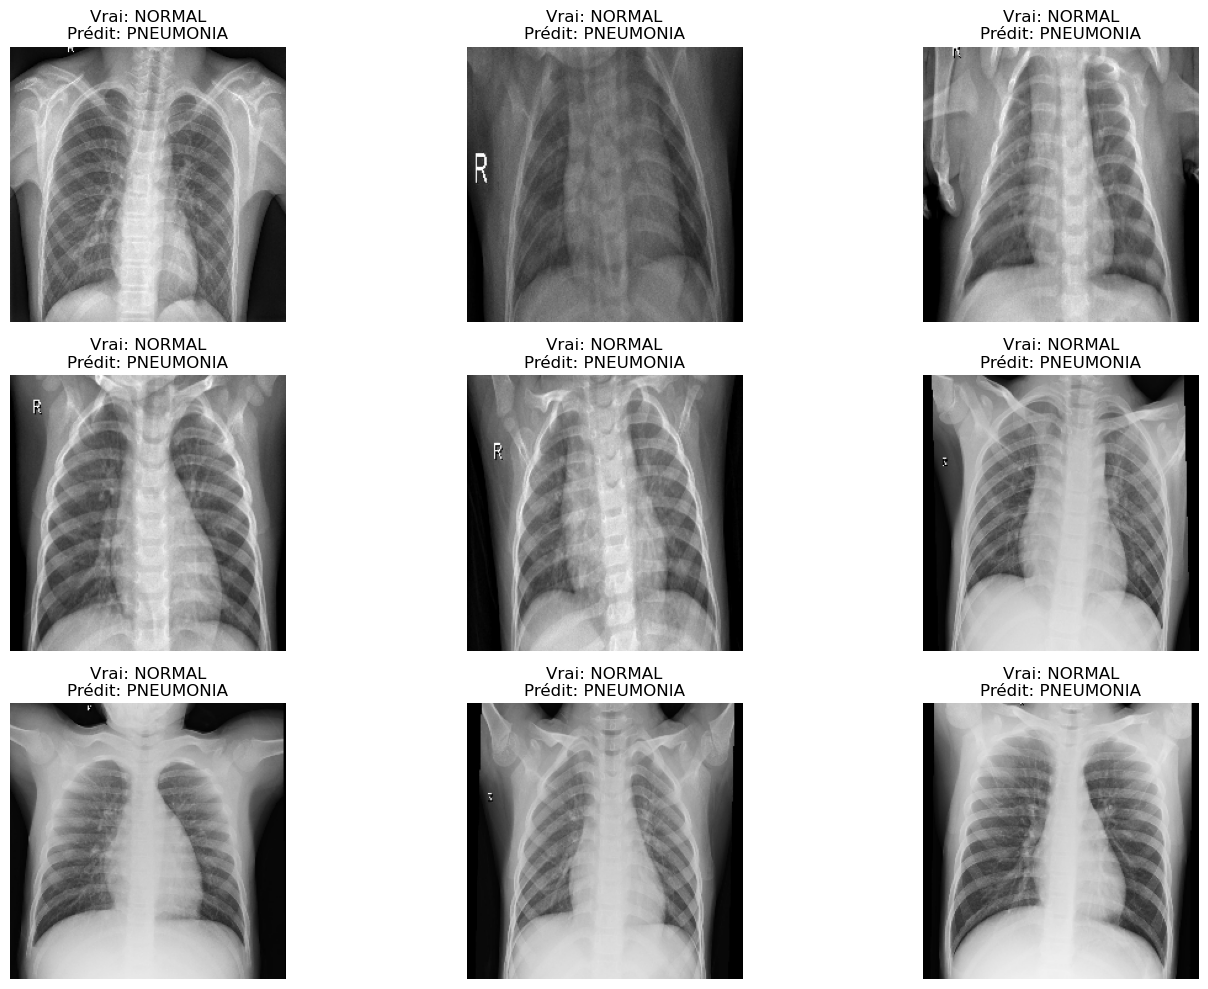

In [137]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Étape 1 : Prédictions sur le test set (sans TTA ici)
test_generator.reset()
pred_probs = model.predict(test_generator, verbose=1)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = test_generator.classes
filenames = test_generator.filenames
class_names = list(test_generator.class_indices.keys())

# Étape 2 : Identifier les erreurs
errors = np.where(pred_labels != true_labels)[0]
print(f"Nombre d'erreurs : {len(errors)}")

# Étape 3 : Afficher quelques erreurs
def plot_errors(errors, n=9):
    plt.figure(figsize=(15, 10))
    for i, idx in enumerate(errors[:n]):
        img_path = test_generator.directory + '/' + filenames[idx]
        img = image.load_img(img_path, target_size=(224, 224))  # taille à adapter selon ton modèle
        plt.subplot(3, 3, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Vrai: {class_names[true_labels[idx]]}\nPrédit: {class_names[pred_labels[idx]]}")
    plt.tight_layout()
    plt.show()

# Afficher les 9 premières erreurs
plot_errors(errors, n=9)


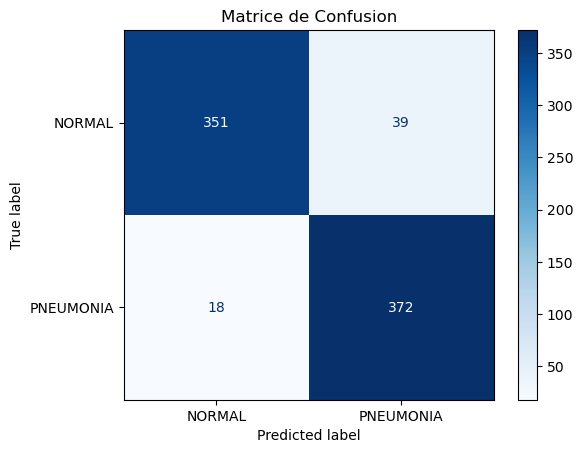

In [139]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de Confusion")
plt.show()
